<a href="https://colab.research.google.com/github/norayyh/AutoInsight-R/blob/main/autoinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install anthropic pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 3.1 MB/s eta 0:00:00


In [4]:
# Upload datasets to Colab from GitHub
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/Iris.csv -O Iris.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/titanic.csv -O titanic.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/housing.csv -O housing.csv
print("Datasets downloaded successfully")

Datasets downloaded successfully


In [5]:
# Install the Anthropic library
import anthropic
from google.colab import userdata

# Initialize the client using the secret API key
client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))

# Send a test request to verify the API connection
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Write Python code using pandas to read iris.csv and print the first 5 rows"}
    ]
)

print(response.content[0].text)

## Reading Iris Dataset with Pandas

```python
import pandas as pd

# Read the CSV file
df = pd.read_csv('iris.csv')

# Print the first 5 rows
print(df.head())
```

### Sample Output
```
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
```

---

### Alternative: Load directly from a URL
```python
import pandas as pd

# Load iris dataset from URL (no local file needed)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Print the first 5 rows
print(df.head())
```

---

### Key Methods Used

| Method/Function | Description |
|----------------|-------------|
| `pd.read_csv()` | Reads a CSV file into a DataFra

In [6]:
import traceback

def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()

# Test the executor with a simple example
test_code = "print('Executor is working!')"
success, message = execute_code(test_code)
print(message)

Executor is working!
Code executed successfully


In [7]:
import re

def clean_code(code: str) -> str:
    """
    Remove markdown code block formatting from generated code.
    """
    code = re.sub(r"```python\n", "", code)
    code = re.sub(r"```", "", code)
    return code.strip()


def generate_code(user_request: str, dataset_path: str) -> str:
    """
    Send a request to Claude to generate Python code for data analysis.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
Write Python code to complete the following task: {user_request}
Only return the Python code, no explanations or markdown formatting.
Only use these libraries: pandas, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def repair_code(user_request: str, previous_code: str, error_message: str, dataset_path: str) -> str:
    """
    Send the failed code and error message back to Claude for repair.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
The user request was: {user_request}

The following code was generated but failed:
{previous_code}

The error message was:
{error_message}

Please fix the code. Only return the corrected Python code, no explanations or markdown formatting.
Only use these libraries: pandas, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()


def run_pipeline(user_request: str, dataset_path: str, max_retries: int = 3) -> dict:
    """
    Run the full self-healing pipeline:
    generate code -> execute -> repair if failed -> retry.
    """
    code = clean_code(generate_code(user_request, dataset_path))

    for attempt in range(max_retries):
        success, message = execute_code(code)

        if success:
            print(f"Success on attempt {attempt + 1}")
            return {"success": True, "attempts": attempt + 1, "code": code}

        print(f"Attempt {attempt + 1} failed. Repairing...")

        if attempt < max_retries - 1:
            code = clean_code(repair_code(user_request, code, message, dataset_path))

    return {"success": False, "attempts": max_retries, "code": code}


# Test the pipeline with an easy task
result = run_pipeline(
    user_request="Calculate the mean, standard deviation, max, and min for each numeric feature",
    dataset_path="Iris.csv"
)
print(result)

              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean   75.500000       5.843333      3.054000       3.758667      1.198667
std    43.445368       0.828066      0.433594       1.764420      0.763161
max   150.000000       7.900000      4.400000       6.900000      2.500000
min     1.000000       4.300000      2.000000       1.000000      0.100000
Success on attempt 1
{'success': True, 'attempts': 1, 'code': "import pandas as pd\n\ndf = pd.read_csv('Iris.csv')\n\nnumeric_df = df.select_dtypes(include='number')\n\nstats = numeric_df.agg(['mean', 'std', 'max', 'min'])\n\nprint(stats)"}


In [8]:
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
!mkdir -p benchmarks
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
print("Datasets and benchmarks downloaded successfully")

Datasets and benchmarks downloaded successfully



Running task 1: [easy] Calculate the mean, standard deviation, max, and min for each numeric feature
              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean   75.500000       5.843333      3.054000       3.758667      1.198667
std    43.445368       0.828066      0.433594       1.764420      0.763161
max   150.000000       7.900000      4.400000       6.900000      2.500000
min     1.000000       4.300000      2.000000       1.000000      0.100000
Success on attempt 1
Result: Success | Attempts: 1

Running task 2: [easy] Plot a histogram for each of the four numeric features


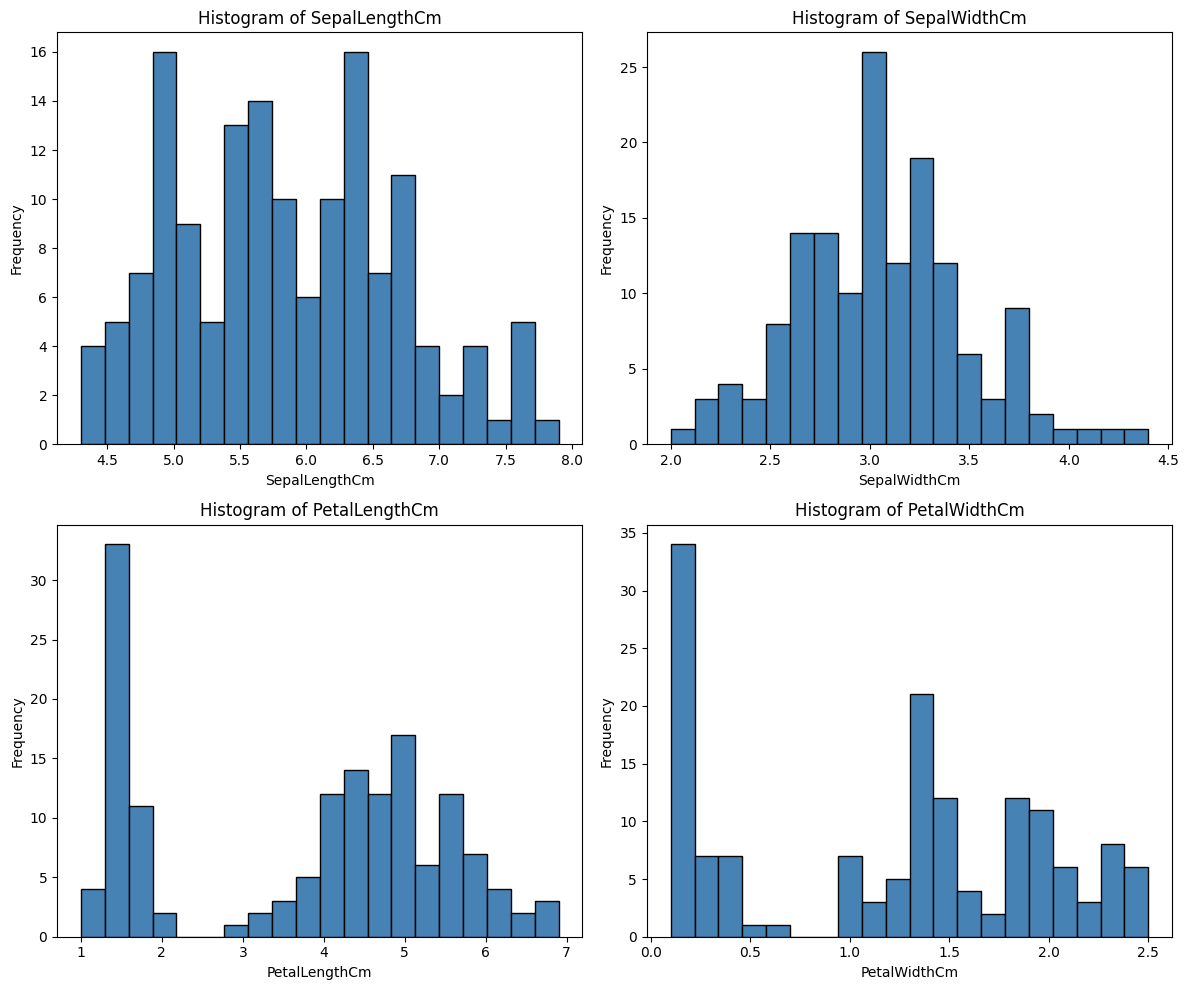

Success on attempt 1
Result: Success | Attempts: 1

Running task 3: [medium] Plot a boxplot of the length column grouped by species


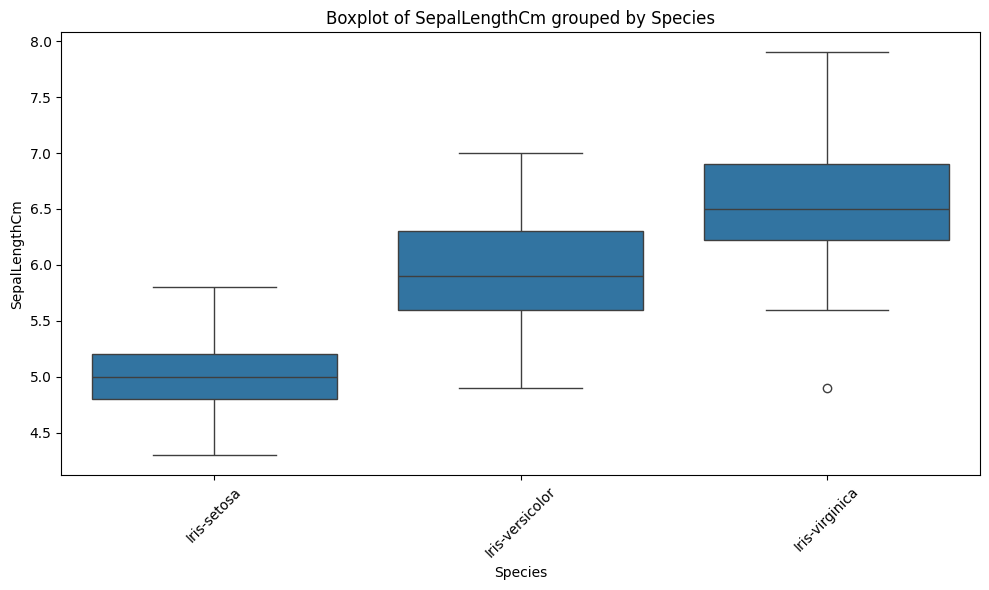

Success on attempt 1
Result: Success | Attempts: 1

Running task 4: [hard] Encode the species column, split the data, train a KNN classifier, and output the accuracy and confusion matrix
First few rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 n

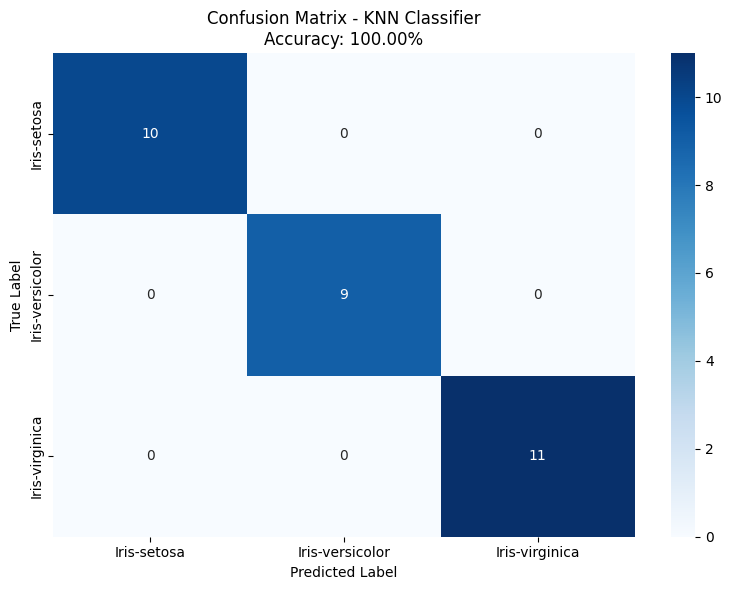


Confusion matrix plot saved as 'confusion_matrix.png'
Success on attempt 1
Result: Success | Attempts: 1

Running task 5: [easy] Calculate the survival rate for each passenger class
Attempt 1 failed. Repairing...
Column names: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
First few rows:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  ze

<string>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...     

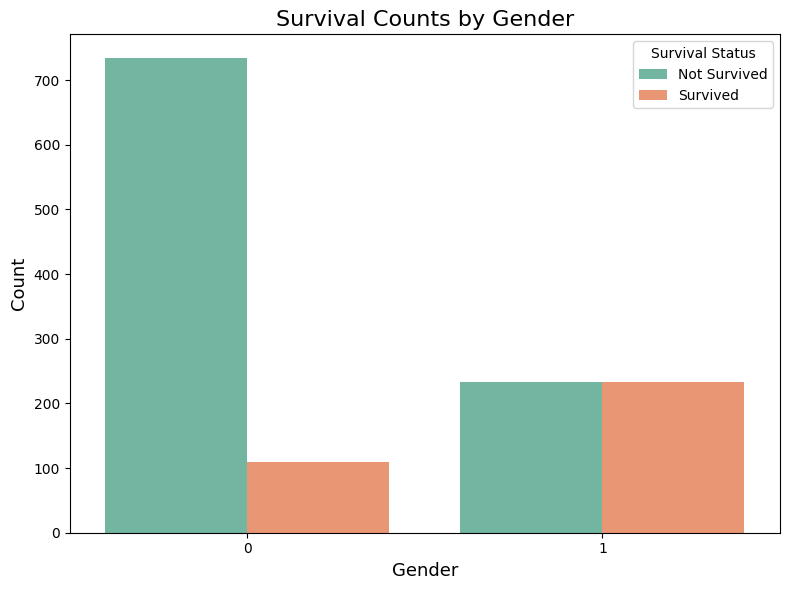

Bar chart saved as 'survival_by_gender.png'
Success on attempt 3
Result: Success | Attempts: 3

Running task 8: [medium] Calculate the average fare paid by survivors vs non-survivors for each passenger class
Attempt 1 failed. Repairing...
Columns in dataset: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
First few rows:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0

<string>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Dataset shape: (1309, 28)

Available columns: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Missing values before cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

Missing values after cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1     

<string>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Dataset shape: (1309, 28)

Available columns: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Missing values before cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

Missing values after cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1     

<string>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Success on attempt 1
Result: Success | Attempts: 1

Running task 12: [easy] Plot a histogram of the house price column
No 'price' column found. Using 'longitude' instead.


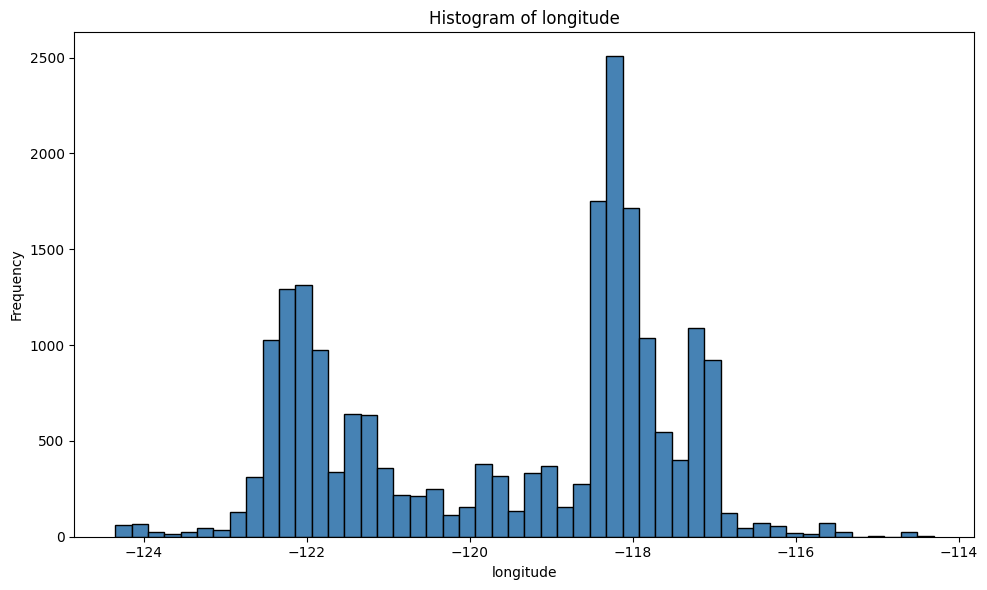

Success on attempt 1
Result: Success | Attempts: 1

Running task 13: [medium] Calculate the correlation between each feature and the target price column, sorted by absolute value
No 'price' column found. Using last column: ocean_proximity
Attempt 1 failed. Repairing...
No 'price' column found. Using last column: ocean_proximity
Attempt 2 failed. Repairing...
No 'price' column found. Using last column: ocean_proximity
Target column 'ocean_proximity' is not numeric. Cannot compute correlation.
Success on attempt 3
Result: Success | Attempts: 3

Running task 14: [medium] Plot a scatter map of house prices using latitude and longitude columns


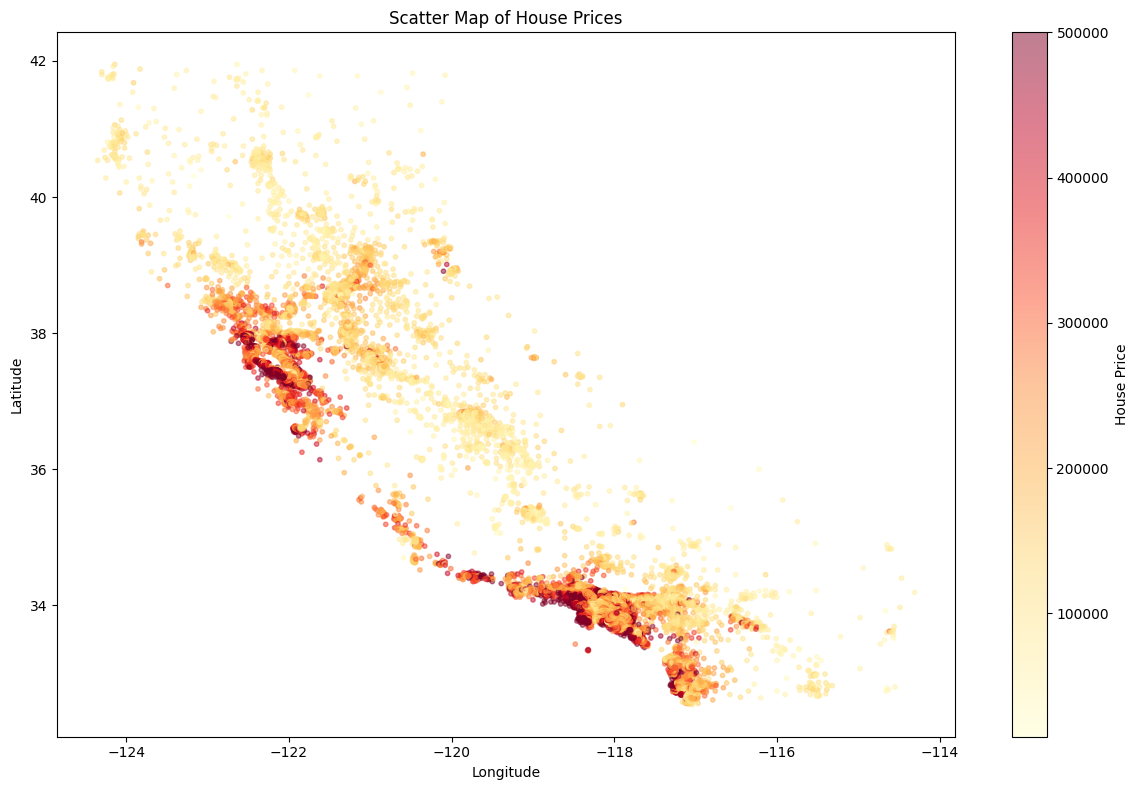

Success on attempt 1
Result: Success | Attempts: 1

Running task 15: [hard] Handle missing values, encode categorical columns if any, train a linear regression model to predict house prices, and output RMSE and R-squared score
Attempt 1 failed. Repairing...
Attempt 2 failed. Repairing...
Attempt 3 failed. Repairing...
Result: Failed | Attempts: 3

===== BENCHMARK RESULTS =====
    id difficulty       category  success  attempts
0    1       easy     statistics     True         1
1    2       easy  visualization     True         1
2    3     medium  visualization     True         1
3    4       hard       modeling     True         1
4    5       easy     statistics     True         2
5    6       easy       cleaning     True         1
6    7     medium  visualization     True         3
7    8     medium     statistics    False         3
8    9       hard       cleaning    False         3
9   10       hard       modeling     True         3
10  11       easy       cleaning     True       

In [9]:
import json
import pandas as pd

# Load benchmark tasks
with open('benchmarks/prompts.json', 'r') as f:
    benchmarks = json.load(f)['benchmarks']

# Dataset path mapping
dataset_paths = {
    "Iris.csv": "Iris.csv",
    "titanic.csv": "titanic.csv",
    "housing.csv": "housing.csv"
}

# Run all benchmark tasks with self-healing pipeline
results = []

for task in benchmarks:
    print(f"\nRunning task {task['id']}: [{task['difficulty']}] {task['prompt']}")

    dataset_path = dataset_paths[task['dataset']]
    result = run_pipeline(task['prompt'], dataset_path)

    results.append({
        "id": task['id'],
        "dataset": task['dataset'],
        "difficulty": task['difficulty'],
        "category": task['category'],
        "prompt": task['prompt'],
        "success": result['success'],
        "attempts": result['attempts']
    })

    print(f"Result: {'Success' if result['success'] else 'Failed'} | Attempts: {result['attempts']}")

# Save results to a DataFrame and display summary
df_results = pd.DataFrame(results)
print("\n===== BENCHMARK RESULTS =====")
print(df_results[['id', 'difficulty', 'category', 'success', 'attempts']])
print(f"\nOverall success rate: {df_results['success'].mean()*100:.1f}%")
print(f"Easy success rate: {df_results[df_results['difficulty']=='easy']['success'].mean()*100:.1f}%")
print(f"Medium success rate: {df_results[df_results['difficulty']=='medium']['success'].mean()*100:.1f}%")
print(f"Hard success rate: {df_results[df_results['difficulty']=='hard']['success'].mean()*100:.1f}%")

# Save results to CSV
df_results.to_csv('benchmark_results_selfhealing.csv', index=False)
print("\nResults saved to benchmark_results_selfhealing.csv")